# Programming Assignment 4: Game Abstraction via Multi-Bet Kuhn Poker
## CPSC 631: Intelligent Agents

**Due Date:** Monday, Dec. 1, 2025

**Student Name: Nicholas Garde**  
**Student ID: 227006946**

---

## Overview

In this assignment, you will explore **game abstraction** by implementing a richer version of Kuhn Poker with multiple bet sizes, then studying how different action abstractions affect equilibrium quality.

### Learning Objectives
- Understand extensive-form games with richer action spaces
- Implement action abstraction techniques
- Analyze abstraction quality through equilibrium comparison
- Empirically study the abstraction-exploitation trade-off

### Multi-Bet Kuhn Poker Rules
- **Players:** 2 (P0 and P1)
- **Deck:** 3 cards {Jack=0, Queen=1, King=2}
- **Ante:** Each player puts 1 chip in the pot (pot starts at 2)
- **Deal:** Each player receives one card (uniformly at random)
- **Betting:**
  1. **P0 acts first:** Pass (`p`), Small Bet (`b1` = 1 chip), or Big Bet (`b2` = 2 chips)
  2. If P0 passes:
     - P1 can Pass (`p`), Bet Small (`b1`), or Bet Big (`b2`)
     - If P1 passes: Showdown (pot = 2)
     - If P1 bets: P0 can Call (`c`) or Fold (`f`)
  3. If P0 bets:
     - P1 can Call (`c`) or Fold (`f`)
- **Showdown:** Higher card wins the pot

### Payoffs (to P0)
- **Check-check (`pp`):** Pot = 2, winner gets +1, loser gets -1
- **Small bet fold (`b1f`, `pb1f`):** Bettor wins pot, gets +1 (folder gets -1)
- **Small bet call (`b1c`, `pb1c`):** Pot = 4, winner gets +2, loser gets -2
- **Big bet fold (`b2f`, `pb2f`):** Bettor wins pot, gets +2 (folder gets -2)
- **Big bet call (`b2c`, `pb2c`):** Pot = 6, winner gets +3, loser gets -3

---

## Assignment Structure

**Task 1 (25 pts):** Implement the full Multi-Bet Kuhn game

**Task 2 (25 pts):** Implement action abstraction wrapper

**Task 3 (20 pts):** Train CFR on full game and abstractions

**Task 4 (20 pts):** Evaluate and compare abstraction quality

**Reflection (10 pts):** Analyze abstraction trade-offs

**Extra Credit (+10 pts):** Find optimal abstract bet size

---

## Submission Instructions
1. Complete all `TODO` cells below
2. Run all cells to ensure your code executes without errors
3. Answer the reflection questions
4. Submit this notebook (`.ipynb`) via the course portal

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
import itertools
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

print("Setup complete!")

Setup complete!


## Import CFR from PA3

We'll reuse the CFR implementation from PA3. Below is a complete CFR trainer that you can use directly.

In [2]:
class CFRTrainer:
    """Generic CFR trainer for any game implementing the required interface."""

    def __init__(self, game):
        self.game = game
        self.regret_sum = defaultdict(lambda: np.zeros(10))
        self.strategy_sum = defaultdict(lambda: np.zeros(10))

    def get_strategy(self, infoset: str, num_actions: int) -> np.ndarray:
        """Return current strategy using regret matching."""
        regrets = self.regret_sum[infoset][:num_actions]
        positive_regrets = np.maximum(regrets, 0)
        total = positive_regrets.sum()

        if total > 0:
            return positive_regrets / total
        else:
            return np.ones(num_actions) / num_actions

    def cfr_recursive(
        self,
        cards: Tuple[int, int],
        history: str,
        reach_0: float,
        reach_1: float,
        updating_player: int
    ) -> float:
        """CFR recursion."""
        if self.game.is_terminal(history):
            payoff = self.game.get_payoff(history, cards)
            return payoff if updating_player == 0 else -payoff

        current_player = self.game.get_current_player(history)
        current_card = cards[current_player]
        infoset = self.game.get_information_set(current_card, history, current_player)
        available_actions = self.game.get_available_actions(history)
        num_actions = len(available_actions)

        strategy = self.get_strategy(infoset, num_actions)
        action_values = np.zeros(num_actions)

        for i, action in enumerate(available_actions):
            action_char = self.game.action_to_char(action, history)
            new_history = history + action_char

            if current_player == 0:
                action_values[i] = self.cfr_recursive(
                    cards, new_history,
                    reach_0 * strategy[i], reach_1,
                    updating_player
                )
            else:
                action_values[i] = self.cfr_recursive(
                    cards, new_history,
                    reach_0, reach_1 * strategy[i],
                    updating_player
                )

        node_value = np.dot(strategy, action_values)

        if current_player == updating_player:
            opponent_reach = reach_1 if current_player == 0 else reach_0
            own_reach = reach_0 if current_player == 0 else reach_1

            regrets = action_values - node_value
            self.regret_sum[infoset][:num_actions] += opponent_reach * regrets
            self.strategy_sum[infoset][:num_actions] += own_reach * strategy

        return node_value

    def train(self, iterations: int, verbose: bool = True) -> Dict:
        """Train CFR for specified iterations."""
        history = {'iterations': [], 'values': []}

        cards_deals = list(itertools.permutations([0, 1, 2], 2))

        for iteration in range(1, iterations + 1):
            for cards in cards_deals:
                for player in [0, 1]:
                    self.cfr_recursive(cards, '', 1.0, 1.0, player)

            if verbose and iteration % 1000 == 0:
                print(f"Iteration {iteration}/{iterations}")

        return history

    def get_average_strategy(self, infoset: str, num_actions: int) -> np.ndarray:
        """Get average strategy for an infoset."""
        strategy_sum = self.strategy_sum[infoset][:num_actions]
        total = strategy_sum.sum()

        if total > 0:
            return strategy_sum / total
        else:
            return np.ones(num_actions) / num_actions

print("✓ CFR Trainer loaded")

✓ CFR Trainer loaded


---
## Task 1: Multi-Bet Kuhn Poker Implementation (25 points)

Implement the full game with three actions at root: Pass, Small Bet (1 chip), Big Bet (2 chips).

### Game Tree Structure

```
Root (P0): p, b1, b2
  ├─ p → P1: p, b1, b2
  │   ├─ pp → TERMINAL (showdown)
  │   ├─ pb1 → P0: c, f
  │   │   ├─ pb1c → TERMINAL
  │   │   └─ pb1f → TERMINAL
  │   └─ pb2 → P0: c, f
  │       ├─ pb2c → TERMINAL
  │       └─ pb2f → TERMINAL
  ├─ b1 → P1: c, f
  │   ├─ b1c → TERMINAL
  │   └─ b1f → TERMINAL
  └─ b2 → P1: c, f
      ├─ b2c → TERMINAL
      └─ b2f → TERMINAL
```

### Information Sets
- **P0 root:** `"0"`, `"1"`, `"2"` (card only)
- **P0 after pb1:** `"0pb1"`, `"1pb1"`, `"2pb1"`
- **P0 after pb2:** `"0pb2"`, `"1pb2"`, `"2pb2"`
- **P1 after p:** `"0p"`, `"1p"`, `"2p"`
- **P1 after b1:** `"0b1"`, `"1b1"`, `"2b1"`
- **P1 after b2:** `"0b2"`, `"1b2"`, `"2b2"`

### Valid Histories Reference

**Valid histories you must produce exactly:**

Terminal histories:
- `pp`
- `b1c`, `b1f`
- `b2c`, `b2f`
- `pb1c`, `pb1f`
- `pb2c`, `pb2f`

Intermediate (non-terminal) histories:
- `''` (empty string - root)
- `'p'`, `'b1'`, `'b2'`
- `'pb1'`, `'pb2'`

**Your code must NEVER generate anything outside this set.**

In [5]:
class MultiBetKuhn:
    """Multi-bet Kuhn Poker with two bet sizes."""

    def __init__(self):
        # Action encoding
        self.PASS = 0
        self.BET_SMALL = 1
        self.BET_BIG = 2
        self.CALL = 0  # Same as PASS when responding
        self.FOLD = 1  # Different context

    def action_to_char(self, action: int, history: str = '') -> str:
        """
        Convert action index to character.
        If previous action was a bet (history ends with '1' or '2'),
        then 0='c' (call), 1='f' (fold).
        Otherwise actions are: p, b1, b2.
        """
        # Bet-response state
        if history.endswith('1') or history.endswith('2'):  # b1 or b2
            return 'c' if action == 0 else 'f'
        # Betting decision
        return 'p' if action == 0 else ('b1' if action == 1 else 'b2')

    def get_information_set(self, card: int, history: str, player: int) -> str:
        """
        Return information set identifier.

        Args:
            card: Player's card (0=J, 1=Q, 2=K)
            history: Public action history
            player: Current player (0 or 1)

        Returns:
            Infoset string (e.g., "0", "1p", "2pb1")
        """
        # Hints:
        # - P0 at root: just card ("0", "1", "2")
        # - P1 after "p": card + "p" ("0p", "1p", "2p")
        # - P1 after "b1": card + "b1" ("0b1", ...)
        # - P1 after "b2": card + "b2"
        # - P0 after "pb1": card + "pb1" ("0pb1", ...)
        # - P0 after "pb2": card + "pb2"
        return f"{card}{history}"
        

    def is_terminal(self, history: str) -> bool:
        """
        Check if history is terminal.

        Terminal histories:
        - "pp": both pass (showdown)
        - "b1c", "b1f": P0 bet small, P1 called/folded
        - "b2c", "b2f": P0 bet big, P1 called/folded
        - "pb1c", "pb1f": P0 passed, P1 bet small, P0 called/folded
        - "pb2c", "pb2f": P0 passed, P1 bet big, P0 called/folded

        Args:
            history: Action sequence

        Returns:
            True if terminal
        """
        # Hint: Check length and specific patterns
        if history.endswith('f'): return True
        if history.endswith('c'): return True
        if history == "pp": return True
        return False

    def get_payoff(self, history: str, cards: Tuple[int, int]) -> int:
        """
        Return payoff to player 0 at terminal node.

        Args:
            history: Terminal history
            cards: (card_p0, card_p1)

        Returns:
            Payoff to P0 (negative means P1 wins)
        """
        assert self.is_terminal(history), "get_payoff called on non-terminal"

        # Payoff structure:
        # - "pp": showdown, pot=2, winner gets +1
        # - "b1f": P1 folds to small bet, P0 gets +1
        # - "b1c": P1 calls small bet, pot=4, winner gets +2
        # - "b2f": P1 folds to big bet, P0 gets +2
        # - "b2c": P1 calls big bet, pot=6, winner gets +3
        # - "pb1f": P0 folds to P1's small bet, P0 gets -1
        # - "pb1c": P0 calls P1's small bet, pot=4, winner gets +2 (or -2 for P0)
        # - "pb2f": P0 folds to P1's big bet, P0 gets -2
        # - "pb2c": P0 calls P1's big bet, pot=6, winner gets +3 (or -3 for P0)

        # Helper: determine winner at showdown
        def winner_payoff(pot_contribution_per_player: int) -> int:
            if cards[0] > cards[1]:
                return pot_contribution_per_player
            else:
                return -pot_contribution_per_player
        
        if history == "pp": return winner_payoff(1)
        match history[-1]:
            case 'f':
                if history.startswith('p'): return -1*int(history[2])
                else: return int(history[1])
            case 'c':
                if history.startswith('p'): return winner_payoff(int(history[2]) + 1)
                else: return winner_payoff(int(history[1]) + 1)
        raise ValueError(f"Invalid terminal history: {history}")



    def get_available_actions(self, history: str) -> List[int]:
        """
        Return available actions at this history.

        Args:
            history: Current history

        Returns:
            List of action indices
        """
        if self.is_terminal(history):
            return []

        # Root or after single pass: can pass, bet small, or bet big
        if history == '' or history == 'p':
            return [self.PASS, self.BET_SMALL, self.BET_BIG]

        # After any bet: can only call or fold
        if history in ['b1', 'b2', 'pb1', 'pb2']:
            return [self.CALL, self.FOLD]

        return []

    def get_current_player(self, history: str) -> int:
        """
        Return whose turn it is.

        Args:
            history: Current history

        Returns:
            Player index (0 or 1)
        """
        # Empty: P0's turn
        # Single action ('p', 'b1', 'b2'): P1's turn
        # Two actions ('pp' is terminal, but 'pb1', 'pb2'): P0's turn
        # Three actions: terminal

        if history == '':
            return 0
        elif len(history) <= 2:  # 'p', 'b1', 'b2'
            return 1
        else:  # 'pb1', 'pb2', 'b1c', etc.
            return 0 if len(history) == 3 else 1  # 3 chars = P0's turn to respond

### Public Tests for Task 1

In [6]:
# Test Task 1
game = MultiBetKuhn()

# Test 1.1: Information sets
try:
    assert game.get_information_set(0, '', 0) == '0', "Failed: P0 root with J"
    assert game.get_information_set(1, 'p', 1) == '1p', "Failed: P1 after pass with Q"
    assert game.get_information_set(2, 'b1', 1) == '2b1', "Failed: P1 after small bet with K"
    assert game.get_information_set(0, 'pb2', 0) == '0pb2', "Failed: P0 after p-b2 with J"
    print("✓ Task 1.1: Information sets correct")
except (NotImplementedError, AssertionError) as e:
    print(f"✗ Task 1.1: {e}")

# Test 1.2: Terminal detection
try:
    assert game.is_terminal('pp') == True, "pp should be terminal"
    assert game.is_terminal('b1c') == True, "b1c should be terminal"
    assert game.is_terminal('b2f') == True, "b2f should be terminal"
    assert game.is_terminal('pb1c') == True, "pb1c should be terminal"
    assert game.is_terminal('') == False, "root should not be terminal"
    assert game.is_terminal('p') == False, "p should not be terminal"
    assert game.is_terminal('b1') == False, "b1 should not be terminal"
    print("✓ Task 1.2: Terminal detection correct")
except (NotImplementedError, AssertionError) as e:
    print(f"✗ Task 1.2: {e}")

# Test 1.3: Payoffs
try:
    assert game.get_payoff('pp', (2, 1)) == 1, "K vs Q showdown"
    assert game.get_payoff('pp', (0, 1)) == -1, "J vs Q showdown"
    assert game.get_payoff('b1c', (2, 0)) == 2, "K calls J small bet"
    assert game.get_payoff('b1f', (0, 1)) == 1, "Q folds to J small bet"
    assert game.get_payoff('b2c', (1, 2)) == -3, "Q calls K big bet"
    assert game.get_payoff('b2f', (0, 2)) == 2, "K folds to J big bet (bluff)"
    assert game.get_payoff('pb1f', (1, 0)) == -1, "Q folds to J's small bet after pass"
    assert game.get_payoff('pb2c', (2, 1)) == 3, "K calls Q's big bet after pass"
    print("✓ Task 1.3: Payoffs correct")
except (NotImplementedError, AssertionError) as e:
    print(f"✗ Task 1.3: {e}")

print("\n✅ Task 1 tests complete!")

✓ Task 1.1: Information sets correct
✓ Task 1.2: Terminal detection correct
✓ Task 1.3: Payoffs correct

✅ Task 1 tests complete!


---
## Task 2: Action Abstraction Wrapper (25 points)

Implement an abstract game that replaces `{p, b1, b2}` with `{p, B}`, where `B` represents a generic "bet" of configurable size.

### Abstraction Design

The wrapper:
1. Exposes only `{p, B}` to CFR at betting decisions
2. Internally maps `B` to a concrete bet (`b1` or `b2`) based on `bet_size` parameter
3. Uses `bet_size` for payoff calculations

### Two Required Abstractions
- **A₁ (Small-bet abstraction):** `bet_size = 1.0` → `B` behaves like `b1`
- **A₂ (Big-bet abstraction):** `bet_size = 2.0` → `B` behaves like `b2`

In [7]:
class AbstractMultiBetKuhn:
    """
    Abstract wrapper for Multi-Bet Kuhn with generic bet action.

    Maps abstract actions {p, B} to concrete game actions.
    """

    def __init__(self, bet_size: float):
        """
        Initialize abstract game.

        Args:
            bet_size: Size of abstract bet (1.0 for A₁, 2.0 for A₂)
        """
        self.full_game = MultiBetKuhn()
        self.bet_size = bet_size

        # Abstract action encoding
        self.PASS = 0
        self.BET = 1  # Generic bet
        self.CALL = 0
        self.FOLD = 1

    def action_to_char(self, action: int, history: str = '') -> str:
        """
        Convert abstract action to character.
        If previous action was a bet (history ends with 'B'),
        then 0='c' (call), 1='f' (fold).
        Otherwise: 0='p', 1='B'.
        """
        # Bet-response state
        if history.endswith('B'):
            return 'c' if action == 0 else 'f'
        # Betting decision
        return 'p' if action == 0 else 'B'

    def _map_abstract_to_concrete(self, history: str) -> str:
        """
        Map abstract history to concrete history.

        Replace every standalone 'B' with:
        - 'b1' if bet_size == 1.0
        - 'b2' if bet_size == 2.0
        Other characters (p, c, f) must remain unchanged.
        History strings must remain valid sequences like 'pB', 'Bc', 'pBc', 'Bf'.

        Args:
            history: Abstract history (may contain 'B')

        Returns:
            Concrete history with 'b1' or 'b2'
        """
        # Hint: Replace 'B' with 'b1' if bet_size == 1.0, else 'b2'
        return history.replace('B', 'b1' if self.bet_size == 1.0 else 'b2')

    def get_information_set(self, card: int, history: str, player: int) -> str:
        """
        Return information set in abstract game.

        Note: Infosets use abstract history (with 'B'), but we can
        reuse the same naming as full game.
        """
        # Map to concrete for infoset naming
        concrete_history = self._map_abstract_to_concrete(history)
        return self.full_game.get_information_set(card, concrete_history, player)

    def is_terminal(self, history: str) -> bool:
        """Check if abstract history is terminal."""
        concrete_history = self._map_abstract_to_concrete(history)
        return self.full_game.is_terminal(concrete_history)

    def get_payoff(self, history: str, cards: Tuple[int, int]) -> float:
        """
        Return payoff using abstract bet size.

        This is where abstraction affects the game: payoffs are
        computed as if 'B' were a bet of size self.bet_size.
        """
        # Strategy:
        # 1. Map abstract history to concrete
        # 2. Use full_game.get_payoff() with mapped history
        # Note: The mapping ensures correct bet size in payoffs
        concrete_history = self._map_abstract_to_concrete(history)
        return self.full_game.get_payoff(concrete_history, cards)

    def get_available_actions(self, history: str) -> List[int]:
        """
        Return available abstract actions.

        At betting decisions: [PASS, BET]
        At bet responses: [CALL, FOLD]
        """
        # Hint:
        # - Betting decision states: history '' or history 'p'
        #   → actions = [PASS, BET]
        # - Response states: history in {'B', 'pB'}
        #   → actions = [CALL, FOLD]
        if 'B' in history:
            return [self.CALL, self.FOLD]
        else:
            return [self.PASS, self.BET]

    def get_current_player(self, history: str) -> int:
        """Return current player in abstract game."""
        concrete_history = self._map_abstract_to_concrete(history)
        return self.full_game.get_current_player(concrete_history)

### Public Tests for Task 2

In [8]:
# Test Task 2: Abstract game wrapper

# Test A₁ (small bet abstraction)
try:
    a1 = AbstractMultiBetKuhn(bet_size=1.0)

    # Test action space
    assert a1.get_available_actions('') == [0, 1], "Root should have [p, B]"
    assert a1.get_available_actions('p') == [0, 1], "After pass should have [p, B]"
    assert a1.get_available_actions('B') == [0, 1], "After bet should have [CALL, FOLD]"
    print("✓ Task 2.1: Abstract action space correct")

    # Test mapping
    assert a1._map_abstract_to_concrete('pB') == 'pb1', "A₁ should map B→b1"
    assert a1._map_abstract_to_concrete('Bc') == 'b1c', "A₁ should map B→b1"
    print("✓ Task 2.2: A₁ mapping correct")

    # Test payoffs in A₁
    assert a1.get_payoff('Bc', (2, 0)) == 2, "A₁: K calls J bet should be +2"
    assert a1.get_payoff('Bf', (0, 1)) == 1, "A₁: Q folds to J bet should be +1"
    print("✓ Task 2.3: A₁ payoffs correct")

except (NotImplementedError, AssertionError) as e:
    print(f"✗ Task 2 (A₁): {e}")

# Test A₂ (big bet abstraction)
try:
    a2 = AbstractMultiBetKuhn(bet_size=2.0)

    # Test mapping
    assert a2._map_abstract_to_concrete('pB') == 'pb2', "A₂ should map B→b2"
    assert a2._map_abstract_to_concrete('Bc') == 'b2c', "A₂ should map B→b2"
    print("✓ Task 2.4: A₂ mapping correct")

    # Test payoffs in A₂
    assert a2.get_payoff('Bc', (2, 0)) == 3, "A₂: K calls J bet should be +3"
    assert a2.get_payoff('Bf', (0, 1)) == 2, "A₂: Q folds to J bet should be +2"
    print("✓ Task 2.5: A₂ payoffs correct")

except (NotImplementedError, AssertionError) as e:
    print(f"✗ Task 2 (A₂): {e}")

print("\n✅ Task 2 tests complete!")

✓ Task 2.1: Abstract action space correct
✓ Task 2.2: A₁ mapping correct
✓ Task 2.3: A₁ payoffs correct
✓ Task 2.4: A₂ mapping correct
✓ Task 2.5: A₂ payoffs correct

✅ Task 2 tests complete!


---
## Task 3: Training Pipeline (20 points)

Train CFR on three games:
1. Full Multi-Bet Kuhn (with `{p, b1, b2}`)
2. Abstract game A₁ (bet_size=1.0)
3. Abstract game A₂ (bet_size=2.0)

For each game, train for 10,000 iterations and record the equilibrium strategies.

**Note:** Task 3 contains three independent NotImplementedError placeholders.
You may comment out sections temporarily to test earlier parts.

In [15]:
def train_full_and_abstract(iterations: int = 10000, verbose: bool = True):
    """
    Train CFR on full game and both abstractions.

    Args:
        iterations: Number of CFR iterations
        verbose: Print progress

    Returns:
        Dictionary with trainers for each game
    """
    results = {}

    # Train on full game
    # 1. Create MultiBetKuhn instance
    # 2. Create CFRTrainer with that game
    # 3. Call train() for specified iterations
    # 4. Store trainer in results['full']

    if verbose:
        print("\n" + "="*60)
        print("Training full Multi-Bet Kuhn...")
        print("="*60)

    game = MultiBetKuhn()
    trainer_full = CFRTrainer(game)
    trainer_full.train(iterations, verbose=verbose)
    results['full'] = trainer_full


    # Train on A₁ (small bet abstraction)
    if verbose:
        print("\n" + "="*60)
        print("Training A₁ (bet_size=1.0)...")
        print("="*60)

    game = AbstractMultiBetKuhn(bet_size=1.0)
    trainer1 = CFRTrainer(game)
    trainer1.train(iterations, verbose=verbose)
    results['a1'] = trainer1

    # Train on A₂ (big bet abstraction)
    if verbose:
        print("\n" + "="*60)
        print("Training A₂ (bet_size=2.0)...")
        print("="*60)

    game = AbstractMultiBetKuhn(bet_size=2.0)
    trainer2 = CFRTrainer(game)
    trainer2.train(iterations, verbose=verbose)
    results['a2'] = trainer2

    return results

### Run Training

In [30]:
# Train all three games
print("Starting training pipeline...\n")
trainers = train_full_and_abstract(iterations=10000, verbose=True)
print("\n✅ Training complete!")

Starting training pipeline...


Training full Multi-Bet Kuhn...
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000

Training A₁ (bet_size=1.0)...
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000

Training A₂ (bet_size=2.0)...
Iteration 1000/10000
Iteration 2000/10000
Iteration 3000/10000
Iteration 4000/10000
Iteration 5000/10000
Iteration 6000/10000
Iteration 7000/10000
Iteration 8000/10000
Iteration 9000/10000
Iteration 10000/10000

✅ Training complete!


---
## Task 4: Evaluation and Analysis (20 points)

Evaluate the quality of abstract strategies by:
1. Computing equilibrium values in each game
2. Comparing abstract strategies to full-game strategies
3. Visualizing the differences

In [17]:
def compute_p0_equilibrium_value(trainer: CFRTrainer) -> float:
    """
    Compute P0's expected value at equilibrium.

    Args:
        trainer: Trained CFR instance

    Returns:
        Expected value for P0 (should be close to 0 in symmetric games)
    """
    # Hint:
    # You may reuse cfr_recursive(cards, '', 1.0, 1.0, 0) as a black-box
    # evaluator, which returns the value of the equilibrium strategy for P0.
    # (This works because regrets and average strategies have been accumulated.)
    #
    # Strategy:
    # 1. For each card deal (6 permutations)
    # 2. Call cfr_recursive to get equilibrium value
    # 3. Average over all deals
    deals = [(0,1), (0,2), (1,0), (1,2), (2,0), (2,1)]
    total_value = 0.0
    for cards in deals:
        total_value += trainer.cfr_recursive(cards, '', 1.0, 1.0, 0)
    return total_value / len(deals)


def compare_strategies(trainers: Dict) -> Dict:
    """
    Compare strategies across full and abstract games.

    Args:
        trainers: Dictionary with 'full', 'a1', 'a2' trainers

    Returns:
        Dictionary with comparison metrics
    """
    results = {}

    # Compute equilibrium values for each game
    # results['full_value'] = ...
    # results['a1_value'] = ...
    # results['a2_value'] = ...
    results['full_value'] = compute_p0_equilibrium_value(trainers['full'])
    results['a1_value'] = compute_p0_equilibrium_value(trainers['a1'])
    results['a2_value'] = compute_p0_equilibrium_value(trainers['a2'])

    return results

def plot_equilibrium_comparison(results: Dict):
    """
    Visualize equilibrium values across games.

    Args:
        results: Dictionary with equilibrium values
    """
    # Create bar plot comparing equilibrium values
    # X-axis: ['Full Game', 'A₁ (bet=1)', 'A₂ (bet=2)']
    # Y-axis: P0's equilibrium value

    labels = ['Full Game', 'A₁ (bet=1)', 'A₂ (bet=2)']
    values = [results['full_value'], results['a1_value'], results['a2_value']]
    plt.bar(labels, values, color=['blue', 'orange', 'green'])
    plt.ylabel("P0's Equilibrium Value")
    plt.title("Equilibrium Value Comparison Across Games")
    plt.show()

### Run Evaluation

Evaluating equilibrium strategies...


EQUILIBRIUM VALUE COMPARISON
Full Game:        -0.067868
A₁ (bet_size=1):  -0.056859
A₂ (bet_size=2):  -0.068458


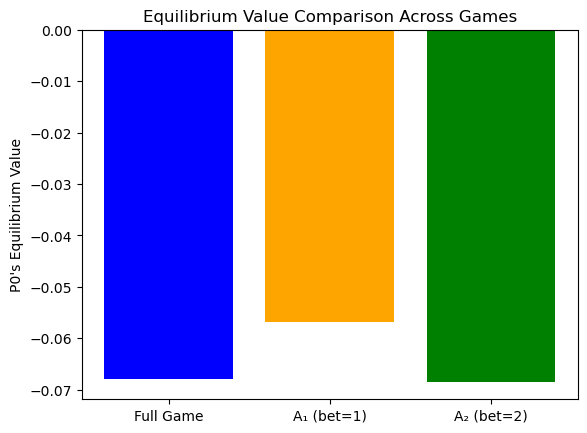

In [18]:
# Evaluate all games
print("Evaluating equilibrium strategies...\n")

comparison_results = compare_strategies(trainers)

print("\n" + "="*60)
print("EQUILIBRIUM VALUE COMPARISON")
print("="*60)
print(f"Full Game:        {comparison_results.get('full_value', 'N/A'):.6f}")
print(f"A₁ (bet_size=1):  {comparison_results.get('a1_value', 'N/A'):.6f}")
print(f"A₂ (bet_size=2):  {comparison_results.get('a2_value', 'N/A'):.6f}")
print("="*60)

# Visualize
plot_equilibrium_comparison(comparison_results)

### Strategy Display

In [20]:
# Display learned strategies for key infosets
print("\n" + "="*60)
print("LEARNED STRATEGIES (P0 with Jack at root)")
print("="*60)

# Full game: P0 with Jack has 3 actions [p, b1, b2]
full_trainer = trainers['full']
full_strategy = full_trainer.get_average_strategy('0', 3)
print(f"\nFull Game (3 actions):")
print(f"  Pass:      {full_strategy[0]:.3f}")
print(f"  Bet Small: {full_strategy[1]:.3f}")
print(f"  Bet Big:   {full_strategy[2]:.3f}")

# A₁: P0 with Jack has 2 actions [p, B]
a1_trainer = trainers['a1']
a1_strategy = a1_trainer.get_average_strategy('0', 2)
print(f"\nA₁ Abstract (2 actions):")
print(f"  Pass: {a1_strategy[0]:.3f}")
print(f"  Bet:  {a1_strategy[1]:.3f}")

# A₂: P0 with Jack has 2 actions [p, B]
a2_trainer = trainers['a2']
a2_strategy = a2_trainer.get_average_strategy('0', 2)
print(f"\nA₂ Abstract (2 actions):")
print(f"  Pass: {a2_strategy[0]:.3f}")
print(f"  Bet:  {a2_strategy[1]:.3f}")

print("\n" + "="*60)
print("LEARNED STRATEGIES (P0 with Queen at root)")
print("="*60)

# Full game: P0 with Jack has 3 actions [p, b1, b2]
full_trainer = trainers['full']
full_strategy = full_trainer.get_average_strategy('1', 3)
print(f"\nFull Game (3 actions):")
print(f"  Pass:      {full_strategy[0]:.3f}")
print(f"  Bet Small: {full_strategy[1]:.3f}")
print(f"  Bet Big:   {full_strategy[2]:.3f}")

# A₁: P0 with Jack has 2 actions [p, B]
a1_trainer = trainers['a1']
a1_strategy = a1_trainer.get_average_strategy('1', 2)
print(f"\nA₁ Abstract (2 actions):")
print(f"  Pass: {a1_strategy[0]:.3f}")
print(f"  Bet:  {a1_strategy[1]:.3f}")

# A₂: P0 with Jack has 2 actions [p, B]
a2_trainer = trainers['a2']
a2_strategy = a2_trainer.get_average_strategy('1', 2)
print(f"\nA₂ Abstract (2 actions):")
print(f"  Pass: {a2_strategy[0]:.3f}")
print(f"  Bet:  {a2_strategy[1]:.3f}")

print("\n" + "="*60)
print("LEARNED STRATEGIES (P0 with King at root)")
print("="*60)

# Full game: P0 with Jack has 3 actions [p, b1, b2]
full_trainer = trainers['full']
full_strategy = full_trainer.get_average_strategy('2', 3)
print(f"\nFull Game (3 actions):")
print(f"  Pass:      {full_strategy[0]:.3f}")
print(f"  Bet Small: {full_strategy[1]:.3f}")
print(f"  Bet Big:   {full_strategy[2]:.3f}")

# A₁: P0 with Jack has 2 actions [p, B]
a1_trainer = trainers['a1']
a1_strategy = a1_trainer.get_average_strategy('2', 2)
print(f"\nA₁ Abstract (2 actions):")
print(f"  Pass: {a1_strategy[0]:.3f}")
print(f"  Bet:  {a1_strategy[1]:.3f}")

# A₂: P0 with Jack has 2 actions [p, B]
a2_trainer = trainers['a2']
a2_strategy = a2_trainer.get_average_strategy('2', 2)
print(f"\nA₂ Abstract (2 actions):")
print(f"  Pass: {a2_strategy[0]:.3f}")
print(f"  Bet:  {a2_strategy[1]:.3f}")


LEARNED STRATEGIES (P0 with Jack at root)

Full Game (3 actions):
  Pass:      0.398
  Bet Small: 0.405
  Bet Big:   0.197

A₁ Abstract (2 actions):
  Pass: 0.686
  Bet:  0.314

A₂ Abstract (2 actions):
  Pass: 0.804
  Bet:  0.196

LEARNED STRATEGIES (P0 with Queen at root)

Full Game (3 actions):
  Pass:      0.000
  Bet Small: 0.496
  Bet Big:   0.503

A₁ Abstract (2 actions):
  Pass: 1.000
  Bet:  0.000

A₂ Abstract (2 actions):
  Pass: 0.000
  Bet:  1.000

LEARNED STRATEGIES (P0 with King at root)

Full Game (3 actions):
  Pass:      0.000
  Bet Small: 0.000
  Bet Big:   1.000

A₁ Abstract (2 actions):
  Pass: 0.044
  Bet:  0.956

A₂ Abstract (2 actions):
  Pass: 0.000
  Bet:  1.000


---
## Reflection Questions (10 points total)

Answer the following questions based on your implementation and results.

### Question 1: Abstraction Effects (3 points)

Why do A₁ and A₂ produce different equilibrium values even though they use the same abstract action space {p, B}? What does this tell us about how action abstraction affects game solutions?

**Your Answer:**

A₁ and A₂ have different loss/reward values, our CFR trainers find different equilibriums because the risk of betting is different. Our abstractions remove a sort of confidence and strategy that multibetting provides.\
Looking at our Jack to full-games our trainers bluff less.\
In Queen games A₁ learned to pass to see how the opponent acts whereas A₂ seems to bluff a strong hand.


### Question 2: Safety and Exploitability (3 points)

Which abstraction (A₁ or A₂) is "safer" for P0 to use? Consider what happens if your opponent knows you're using an abstract strategy and can exploit it. Which abstraction is harder to exploit?

**Your Answer:**

A₁ is safer for P0, it has the least loss average over the 6 deals because it reduces risk while the opponent attempts to exploit its actions. Lower risk bets means that while the opponent is beating P0's strategies, P0 is only losing a small bet until it responds by changing its strategy.\
CFR takes time to adjust from being exploited, and A₂ is losing more in each game.\
Variable betting allows our full-game trainer to be less decipherable and less exploitable.

### Question 3: Abstraction-Exploitation Trade-off (4 points)

Explain the abstraction-exploitation trade-off: Why might an opponent do better against an abstract strategy than against the full-game Nash equilibrium? How does this relate to real-world poker AI design?

**Your Answer:**

An abstract strategy is easier to exploit than variable betting, reducing P0's actions made those actions easier to interpret and take advantage of. Real-world poker is rooted in ambiguity in order to make it difficult for your opponents to read your actions. Real-world poker AI design is also able to leverage statistical modeling to motivate actions (betting aggression/bluffing).

---
## Extra Credit: Optimal Bet Size Search (+10 points)

Explore whether there's a "better" abstract bet size than 1.0 or 2.0.

### Task
1. Parameterize your abstract game to accept any `bet_size` ∈ [1.0, 2.0]
2. Train CFR for `bet_size ∈ {1.0, 1.25, 1.5, 1.75, 2.0}`
3. Compute equilibrium value for each
4. Compare which bet size produces values closest to the full game
5. Visualize and analyze results

In [29]:
# (EXTRA CREDIT): Implement bet size sweep

def sweep_bet_sizes(bet_sizes: List[float], iterations: int = 5000) -> Dict:
    """
    Train CFR on abstract games with different bet sizes.

    Args:
        bet_sizes: List of bet sizes to try
        iterations: CFR iterations per size

    Returns:
        Dictionary mapping bet_size -> equilibrium_value
    """
    # Loop over bet sizes, train, compute value
    results = {}
    for bet_size in bet_sizes:
        game = AbstractMultiBetKuhn(bet_size=bet_size)
        trainer = CFRTrainer(game)
        trainer.train(iterations, verbose=False)
        eq_value = compute_p0_equilibrium_value(trainer)
        results[bet_size] = eq_value
        print(f"Bet size {bet_size}: Equilibrium value {eq_value:.6f}")
    return results

def plot_bet_size_sweep(results: Dict, full_game_value: float):
    """
    Plot how equilibrium value varies with bet size.

    Args:
        results: Dictionary {bet_size: equilibrium_value}
        full_game_value: Reference value from full game
    """
    # Create line plot
    # Show horizontal line for full_game_value as reference
    bet_sizes = results.keys()
    values = [results[bs] for bs in bet_sizes]
    plt.plot(bet_sizes, values, marker='o', label='Abstract Game')
    plt.axhline(y=full_game_value, color='r', label='Full Game')
    plt.xlabel('Bet Size')
    plt.ylabel("P0 Equilibrium Value")
    plt.title('Equilibrium Value vs Bet Size')
    plt.legend()
    plt.show()

### Run Extra Credit Analysis

Running bet size sweep...

Bet size 1.0: Equilibrium value -0.057353
Bet size 1.25: Equilibrium value -0.065251
Bet size 1.5: Equilibrium value -0.065251
Bet size 1.75: Equilibrium value -0.065251
Bet size 2.0: Equilibrium value -0.065251

BET SIZE SWEEP RESULTS
Full game value (reference): -0.067868

Bet size 1.00: value = -0.057353, distance = 0.010515
Bet size 1.25: value = -0.065251, distance = 0.002617
Bet size 1.50: value = -0.065251, distance = 0.002617
Bet size 1.75: value = -0.065251, distance = 0.002617
Bet size 2.00: value = -0.065251, distance = 0.002617

✓ Best abstraction: bet_size = 1.25


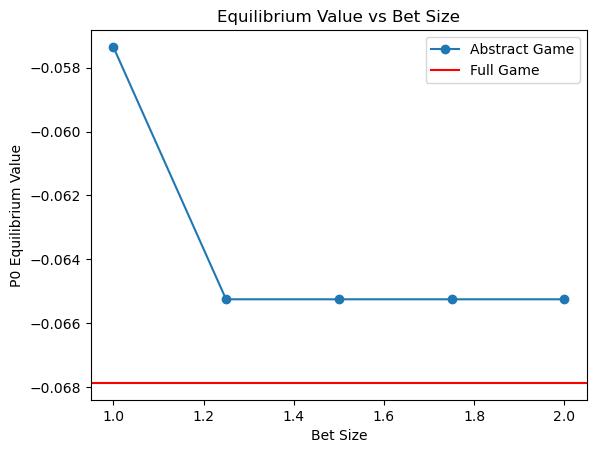


✅ Extra credit analysis complete!


In [31]:
# Extra Credit: This cell only runs if you've implemented the functions above

try:
    print("Running bet size sweep...\n")

    bet_sizes_to_test = [1.0, 1.25, 1.5, 1.75, 2.0]
    sweep_results = sweep_bet_sizes(bet_sizes_to_test, iterations=5000)

    print("\n" + "="*60)
    print("BET SIZE SWEEP RESULTS")
    print("="*60)

    full_value = comparison_results['full_value']
    print(f"Full game value (reference): {full_value:.6f}\n")

    for bet_size in sorted(sweep_results.keys()):
        value = sweep_results[bet_size]
        distance = abs(value - full_value)
        print(f"Bet size {bet_size:.2f}: value = {value:.6f}, distance = {distance:.6f}")

    # Find best bet size
    best_size = min(sweep_results.keys(),
                    key=lambda s: abs(sweep_results[s] - full_value))
    print(f"\n✓ Best abstraction: bet_size = {best_size:.2f}")
    print("="*60)

    # Visualize
    plot_bet_size_sweep(sweep_results, full_value)

    print("\n✅ Extra credit analysis complete!")

except NotImplementedError:
    print("ℹ Extra credit not attempted")
except Exception as e:
    print(f"❌ Extra credit error: {e}")
    import traceback
    traceback.print_exc()

### Extra Credit Reflection

If you completed the extra credit, answer:

**Does bet_size = 1.5 behave like a "better" abstraction than the extremes (1.0 or 2.0)? Why or why not?**

I haven't adjusted the Abstract class and game class to recieve bets that aren't 1.0 or 2.0 because the strings are built into the history.

---
## Submission Checklist

Before submitting, verify:
- [ ] All `TODO` cells have been completed
- [ ] All code cells run without errors (Kernel → Restart & Run All)
- [ ] Public tests pass
- [ ] Reflection questions are answered
- [ ] Plots are visible in the notebook
- [ ] Your name and student ID are filled in at the top

**Submit:** Upload this `.ipynb` file to the course portal.

---

## Grading Rubric (100 points total + 10 extra credit)

| Component | Points |
|-----------|--------|
| Task 1: Multi-Bet Kuhn Implementation | 25 |
| Task 2: Action Abstraction Wrapper | 25 |
| Task 3: Training Pipeline | 20 |
| Task 4: Evaluation & Analysis | 20 |
| Reflection Questions | 10 |
| **Extra Credit:** Bet size sweep | +10 |

Good luck!